In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ----------------------------------------------------------------------
# SECTION 1: Generate the "mouse" dataset
# ----------------------------------------------------------------------
np.random.seed(0)  # for reproducibility

# 1) 300 points from N([0, 0], [[0.16, 0],[0, 0.16]])
mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

# 2) 100 points from N([0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

# 3) 100 points from N([-0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

# Combine all data
data_X = np.vstack([data1, data2, data3])
N, d = data_X.shape  # should be (500, 2)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# data_X should be shape (N, 2)
# (use your mouse dataset generation from the lab, or any other 2D dataset)
X = data_X

K = 3
gmm = GaussianMixture(
    n_components=K,
    covariance_type="full",
    random_state=0,
    n_init=10
)
gmm.fit(X)


,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


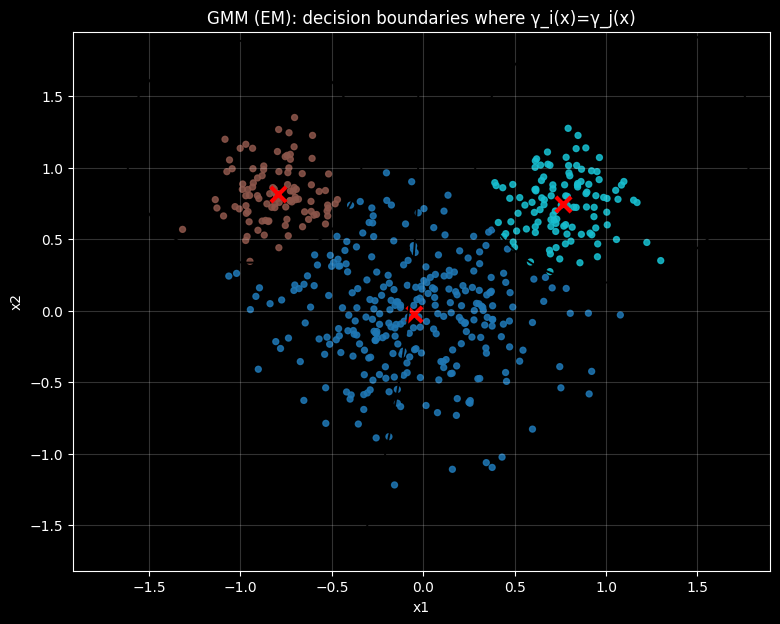

In [8]:
def plot_gmm_boundaries_lines(gmm, X, grid_n=400, padding=0.7):
    # grid_n=400 -> 160k points; you can lower to 250 if slow
    x_min, x_max = X[:,0].min() - padding, X[:,0].max() + padding
    y_min, y_max = X[:,1].min() - padding, X[:,1].max() + padding

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_n),
        np.linspace(y_min, y_max, grid_n)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # responsibilities: shape (grid_points, K)
    resp = gmm.predict_proba(grid)  # γ_{k}(x)
    resp = resp.reshape(grid_n, grid_n, -1)  # (grid_n, grid_n, K)

    labels = gmm.predict(X)

    plt.figure(figsize=(9, 7))

    # scatter of data (hard cluster assignment)
    plt.scatter(X[:,0], X[:,1], c=labels, s=18, cmap="tab10", alpha=0.85)

    # plot boundary lines: γ_i(x) - γ_j(x) = 0
    for i in range(gmm.n_components):
        for j in range(i+1, gmm.n_components):
            diff = resp[:,:,i] - resp[:,:,j]
            plt.contour(xx, yy, diff, levels=[0], colors="k", linewidths=1.4)

    # plot means
    plt.scatter(gmm.means_[:,0], gmm.means_[:,1], c="red", s=120, marker="x", linewidths=3)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("GMM (EM): decision boundaries where γ_i(x)=γ_j(x)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(alpha=0.2)
    plt.show()

plot_gmm_boundaries_lines(gmm, X, grid_n=400, padding=0.6)


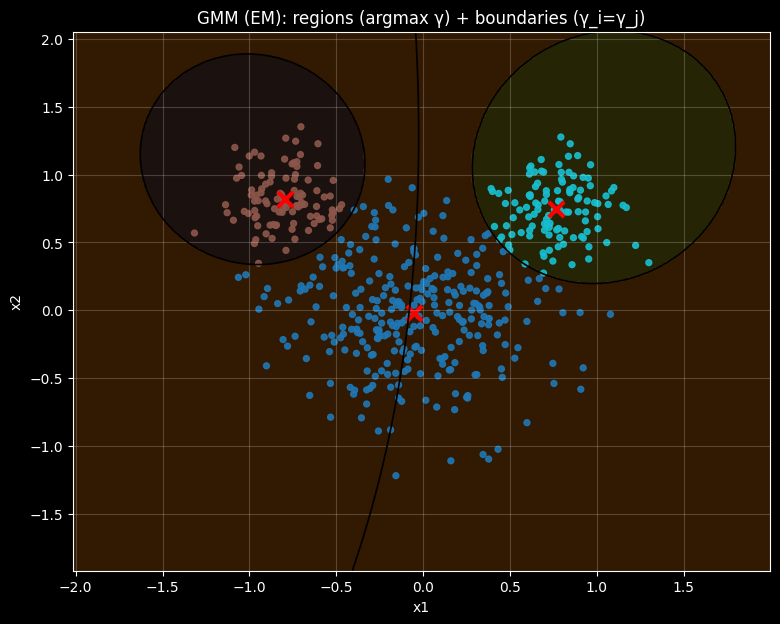

In [9]:
def plot_gmm_regions_and_lines(gmm, X, grid_n=400, padding=0.7):
    x_min, x_max = X[:,0].min() - padding, X[:,0].max() + padding
    y_min, y_max = X[:,1].min() - padding, X[:,1].max() + padding

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_n),
        np.linspace(y_min, y_max, grid_n)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    resp = gmm.predict_proba(grid)
    winner = np.argmax(resp, axis=1).reshape(grid_n, grid_n)
    resp = resp.reshape(grid_n, grid_n, -1)

    labels = gmm.predict(X)

    plt.figure(figsize=(9, 7))

    # background regions
    plt.contourf(xx, yy, winner, levels=np.arange(gmm.n_components+1)-0.5,
                 cmap="tab10", alpha=0.20)

    # data
    plt.scatter(X[:,0], X[:,1], c=labels, s=18, cmap="tab10", alpha=0.9)

    # boundary lines
    for i in range(gmm.n_components):
        for j in range(i+1, gmm.n_components):
            diff = resp[:,:,i] - resp[:,:,j]
            plt.contour(xx, yy, diff, levels=[0], colors="k", linewidths=1.2)

    plt.scatter(gmm.means_[:,0], gmm.means_[:,1], c="red", s=120, marker="x", linewidths=3)
    plt.title("GMM (EM): regions (argmax γ) + boundaries (γ_i=γ_j)")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.grid(alpha=0.2)
    plt.show()

plot_gmm_regions_and_lines(gmm, X)


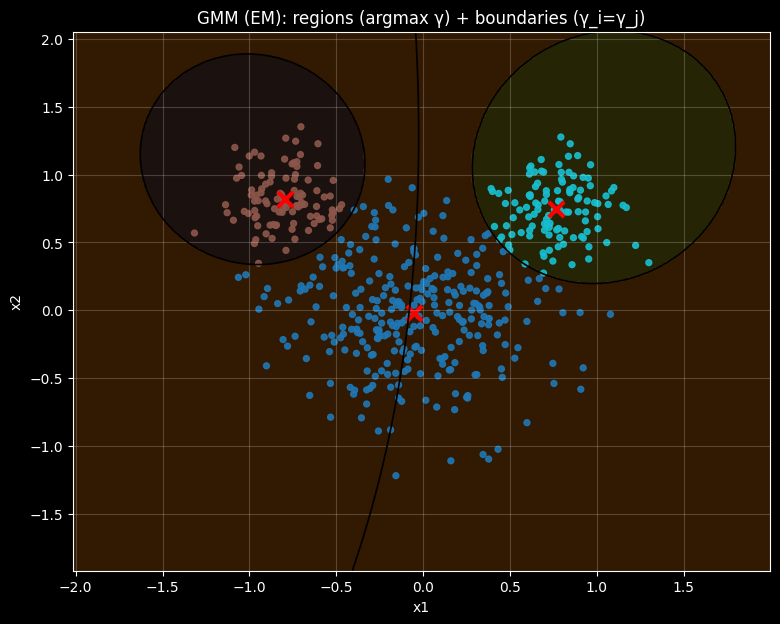

In [10]:
def plot_gmm_regions_and_lines(gmm, X, grid_n=400, padding=0.7):
    x_min, x_max = X[:,0].min() - padding, X[:,0].max() + padding
    y_min, y_max = X[:,1].min() - padding, X[:,1].max() + padding

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_n),
        np.linspace(y_min, y_max, grid_n)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    resp = gmm.predict_proba(grid)
    winner = np.argmax(resp, axis=1).reshape(grid_n, grid_n)
    resp = resp.reshape(grid_n, grid_n, -1)

    labels = gmm.predict(X)

    plt.figure(figsize=(9, 7))

    # background regions
    plt.contourf(xx, yy, winner, levels=np.arange(gmm.n_components+1)-0.5,
                 cmap="tab10", alpha=0.20)

    # data
    plt.scatter(X[:,0], X[:,1], c=labels, s=18, cmap="tab10", alpha=0.9)

    # boundary lines
    for i in range(gmm.n_components):
        for j in range(i+1, gmm.n_components):
            diff = resp[:,:,i] - resp[:,:,j]
            plt.contour(xx, yy, diff, levels=[0], colors="k", linewidths=1.2)

    plt.scatter(gmm.means_[:,0], gmm.means_[:,1], c="red", s=120, marker="x", linewidths=3)
    plt.title("GMM (EM): regions (argmax γ) + boundaries (γ_i=γ_j)")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.grid(alpha=0.2)
    plt.show()

plot_gmm_regions_and_lines(gmm, X)
